# **CESM amip water tracer - annual variability**
plots regarding the annual/seasonal cycle, and its inter-annual variability
This notebook requires a prior storage of integrated water vapour (cell 22 of Sanity checks notebook)

## **Initial Set Up-related**

In [1]:
%matplotlib inline
########## OS Interaction ##########
import os
import sys
import cftime

########## General ##########
import numpy as np
import netCDF4 as nc
import xarray as xr
import scipy as sp
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.colors as colors 
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import ticker
from matplotlib import gridspec
import matplotlib.dates as mdates
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar

########## Cartopy+ Shapely ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from mpl_toolkits.axes_grid1 import make_axes_locatable


### Functions 

In [2]:
# Overall: creates a vertical integration function accounting for totpography and surface pressure
def vert_int_hybrid(ds, var, ds_hybrid):
    g    = 9.80665   # m/s²
    P0   = 100000.   # Pa  (standard reference pressure)

    q    = ds[var]
    PS   = ds_hybrid['PS']    # surface pressure  (Pa)
    hyai = ds_hybrid['hyai']  # interface A coefficients
    hybi = ds_hybrid['hybi']  # interface B coefficients

    # Interface pressures at every grid point & level interface
    P_i = hyai * P0 + hybi * PS          # shape: (time, ilev, lat, lon)

    # Pressure thickness of each model layer
    dp = P_i.diff(dim='ilev')            # shape: (time, ilev-1, lat, lon)
    dp = dp.transpose("time", "ilev", "lat", "lon")

    # Copy dp into a DataArray that shares 'lev' dim with q
    dp_lev = ds[var].copy() * 0.0
    dp_lev.values = dp.values

    # Hydrostatic column integral: Σ (q·dp) / g
    layer_int = (q * dp_lev) / g
    total_int = layer_int.sum(dim='lev', skipna=True)
    return total_int
    
########## Unstack time to have Yearsxmonths #########
def unstack_time(ds_in):
    years = ds_in.groupby('time.year').mean('time').year
    months = ds_in.groupby('time.month').mean('time').month
    
    # make a pandas MultiIndex that is years x months
    midx = pd.MultiIndex.from_product([years.values,months.values], names=("year","month"))
    ds_temp = ds_in.copy()

    # try to multiindex the dataset directly
    ds_temp = ds_temp.assign_coords({'time':midx})
    ds_out = ds_temp.unstack()
    return ds_out

### Variable definition and data path

In [3]:
# Data Path
data_dir =  '/scratch/st-mlague-1/mlague/data/iCESM/'

# Creates a list of atmospheric variables
atm_vars = [ 'LHFLX','Q','TMQ','LNDV','NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV'] # PS is added for the vertical integration
static_vars = ['hyai', 'hybi','PS'] # variables for the hybrid integration

# tracer list,and dictionary associating it with a name
tracer_realnames = ['Q','LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
tracer_shortnames = ['All Land and Oceans','All Land', 'North Pole', 'North America', 'Europe and Northern Africa', 'Eastern Asia', 'Central South America', 'Central Africa', 'Maritime Continent', 'South America', 'South Africa', 'Australia', 'South Pole']
tracer_dict_reversed = dict(zip(tracer_realnames, tracer_shortnames))

# associate month with their name
months_name= dict(zip([1,2,3,4,5,6,7,8,9,10,11,12],['January','Februry','March','April','May','June','July','August','September','October','November','December']))

# case list, dictionary associating it with a name
case_list = ['icesm_continents_sst'] #case list
short_list=['amip'] # case list names
short_names = dict(zip(case_list, short_list))

### Dictionary definition

In [4]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

for case in case_list:
    # Defines the time series directory name for the case
    ts_dir = Path(data_dir) / case / 'TimeSeries'

    # Build the list of atm files with pathlib,
    file_list_atm = []
    ds_static_list = []
    for var in atm_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))

        if not files:
            print(f'oh no, no variables for {var}')
        else:
            for file in files:
                    file_list_atm.append(file)
        print( 'got the data from', var) 
        
    # static variables for the integral function
    for var in static_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))
        if not files:
            print(f'oh no, no file for {var}')
        else:
            ds_static_list.append(xr.open_dataset(files[0], engine='netcdf4'))  # ONE file, ONE var
        print('got the data from', var)
        
    # Open the variables all at once without dropping any years
    #with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ds_temp_atm = xr.open_mfdataset(file_list_atm, engine='netcdf4', compat='override',chunks={'time': 36, 'lev': 30, 'lat': 48, 'lon': 72} )
    ds_temp_atm_short = ds_temp_atm.isel(time=slice(11,323)) # Drops the first year
    ds_temp_static = xr.merge(ds_static_list)
    ds_static_coeffs = ds_temp_static[['hyai', 'hybi', 'P0']]
    ds_static_PS = ds_temp_static['PS'].isel(time=slice(11, 323))
    # Merge everything
    ds_temp_atm_short = xr.merge([ds_temp_atm_short, ds_static_coeffs, ds_static_PS], join='override')

    print('data put together and cut!')
    short = short_names[case]
    ds_temp_atm_short.attrs['title'] = short  # assign the short name as the title
    ts_dict_atm[short] = ds_temp_atm_short.copy()
    del ds_temp_atm, ds_temp_atm_short  # Deletes the temporary data sets

got the data from LHFLX
got the data from Q
got the data from TMQ
got the data from LNDV
got the data from NPV
got the data from NAV
got the data from EUV
got the data from EAV
got the data from CSAV
got the data from CAFV
got the data from MARV
got the data from SAV
got the data from SAFV
got the data from AUSV
got the data from SPV
got the data from hyai
got the data from hybi
got the data from PS
data put together and cut!


In [5]:
# Overall : calculate each grid cell area
R = 6.371e6  # Earth radius (m)

lat_vals = ts_dict_atm['amip'].lat.values  
lon_vals = ts_dict_atm['amip'].lon.values  
lat_top    = np.deg2rad(lat_vals) + np.deg2rad(lat_vals[1] - lat_vals[0]) / 2  # upper edge  ( position - distance /2)
lat_bottom = np.deg2rad(lat_vals) - np.deg2rad(lat_vals[1] - lat_vals[0]) / 2  # lower edge ( position - distance /2)

# spherical area per grid cell in m2 : r^^2* sin(top-bottom lat angle distance )* (lon angle distance)
cell_area = R**2 *  (np.sin(lat_top) - np.sin(lat_bottom))* np.deg2rad(lon_vals[1] - lon_vals[0]) # shape : lat 

# np=> Xarray to be alble to work with lats :
cell_area = xr.DataArray(cell_area, dims=['lat'], coords={'lat': ts_dict_atm['amip'].lat.values}) 
#print (cell_area)

In [6]:
#Overall : Dictionary linking each tracer to its number of cells and total surface
landfrac_path= Path(data_dir) / 'icesm_continents_sst' / 'icesm_continents_sst.clm2.h0.1979-01.nc'
ds_landfrac=xr.open_dataset(landfrac_path)
landfrac = ds_landfrac['landfrac'].load()

tracer_regions = {
    'LNDV': {'lat': (-90,  90),  'lon': (0,   360)},
    'NPV':  {'lat': ( 60,  90),  'lon': (0,   360)},
    'NAV':  {'lat': ( 20,  60),  'lon': (190, 340)},
    'EUV':  {'lat': ( 20,  60),  'lon': (340,  60)},
    'EAV':  {'lat': ( 20,  60),  'lon': (60,  190)},
    'CSAV': {'lat': (-20,  20),  'lon': (190, 340)},
    'CAFV': {'lat': (-20,  20),  'lon': (340,  60)},
    'MARV': {'lat': (-20,  20),  'lon': (60,  190)},
    'SAV':  {'lat': (-60, -20),  'lon': (190, 340)},
    'SAFV': {'lat': (-60, -20),  'lon': (340,  60)},
    'AUSV': {'lat': (-60, -20),  'lon': (60,  190)},
    'SPV':  {'lat': (-90, -60),  'lon': (0,   360)},}

surface_land_cells_dict = {}
n_land_cells_dict = {}
land_mask_dict= {}

cell_area = cell_area.assign_coords(lat=landfrac.lat)# to have the exact same latitude, otherwise the multiplucation fails

for tracer, region in tracer_regions.items():
    lat_min, lat_max = region['lat']
    lon_min, lon_max = region['lon']
    lat_mask = landfrac.sel(lat=slice(lat_min, lat_max))
    if lon_min <= lon_max:
        land_mask_dict[tracer] = lat_mask.sel(lon=slice(lon_min, lon_max))
    else:
        land_mask_dict[tracer] = xr.concat([lat_mask.sel(lon=slice(lon_min, 360)),lat_mask.sel(lon=slice(0, lon_max)),],dim="lon",)

    n_land_cells_dict[tracer] = (land_mask_dict[tracer]> 0.5).sum(['lat', 'lon'])# number of land cell for each tracer grid
    surface_land_cells_dict[tracer] =(land_mask_dict[tracer]*cell_area).sum(['lat', 'lon']) # land surface in m2 for each tracer grid
    print(f'{tracer}: {surface_land_cells_dict[tracer].values:.4e} m2,{n_land_cells_dict[tracer].values} cells')


LNDV: 1.4877e+14 m2,4739 cells
NPV: 1.6942e+13 m2,799 cells
NAV: 1.5815e+13 m2,388 cells
EUV: 2.0381e+13 m2,462 cells
EAV: 2.5531e+13 m2,604 cells
CSAV: 1.3922e+13 m2,243 cells
CAFV: 2.1707e+13 m2,377 cells
MARV: 7.3791e+12 m2,119 cells
SAV: 5.0785e+12 m2,105 cells
SAFV: 2.6094e+12 m2,50 cells
AUSV: 6.0850e+12 m2,118 cells
SPV: 1.4127e+13 m2,1493 cells


## Results and analysis

### line plots

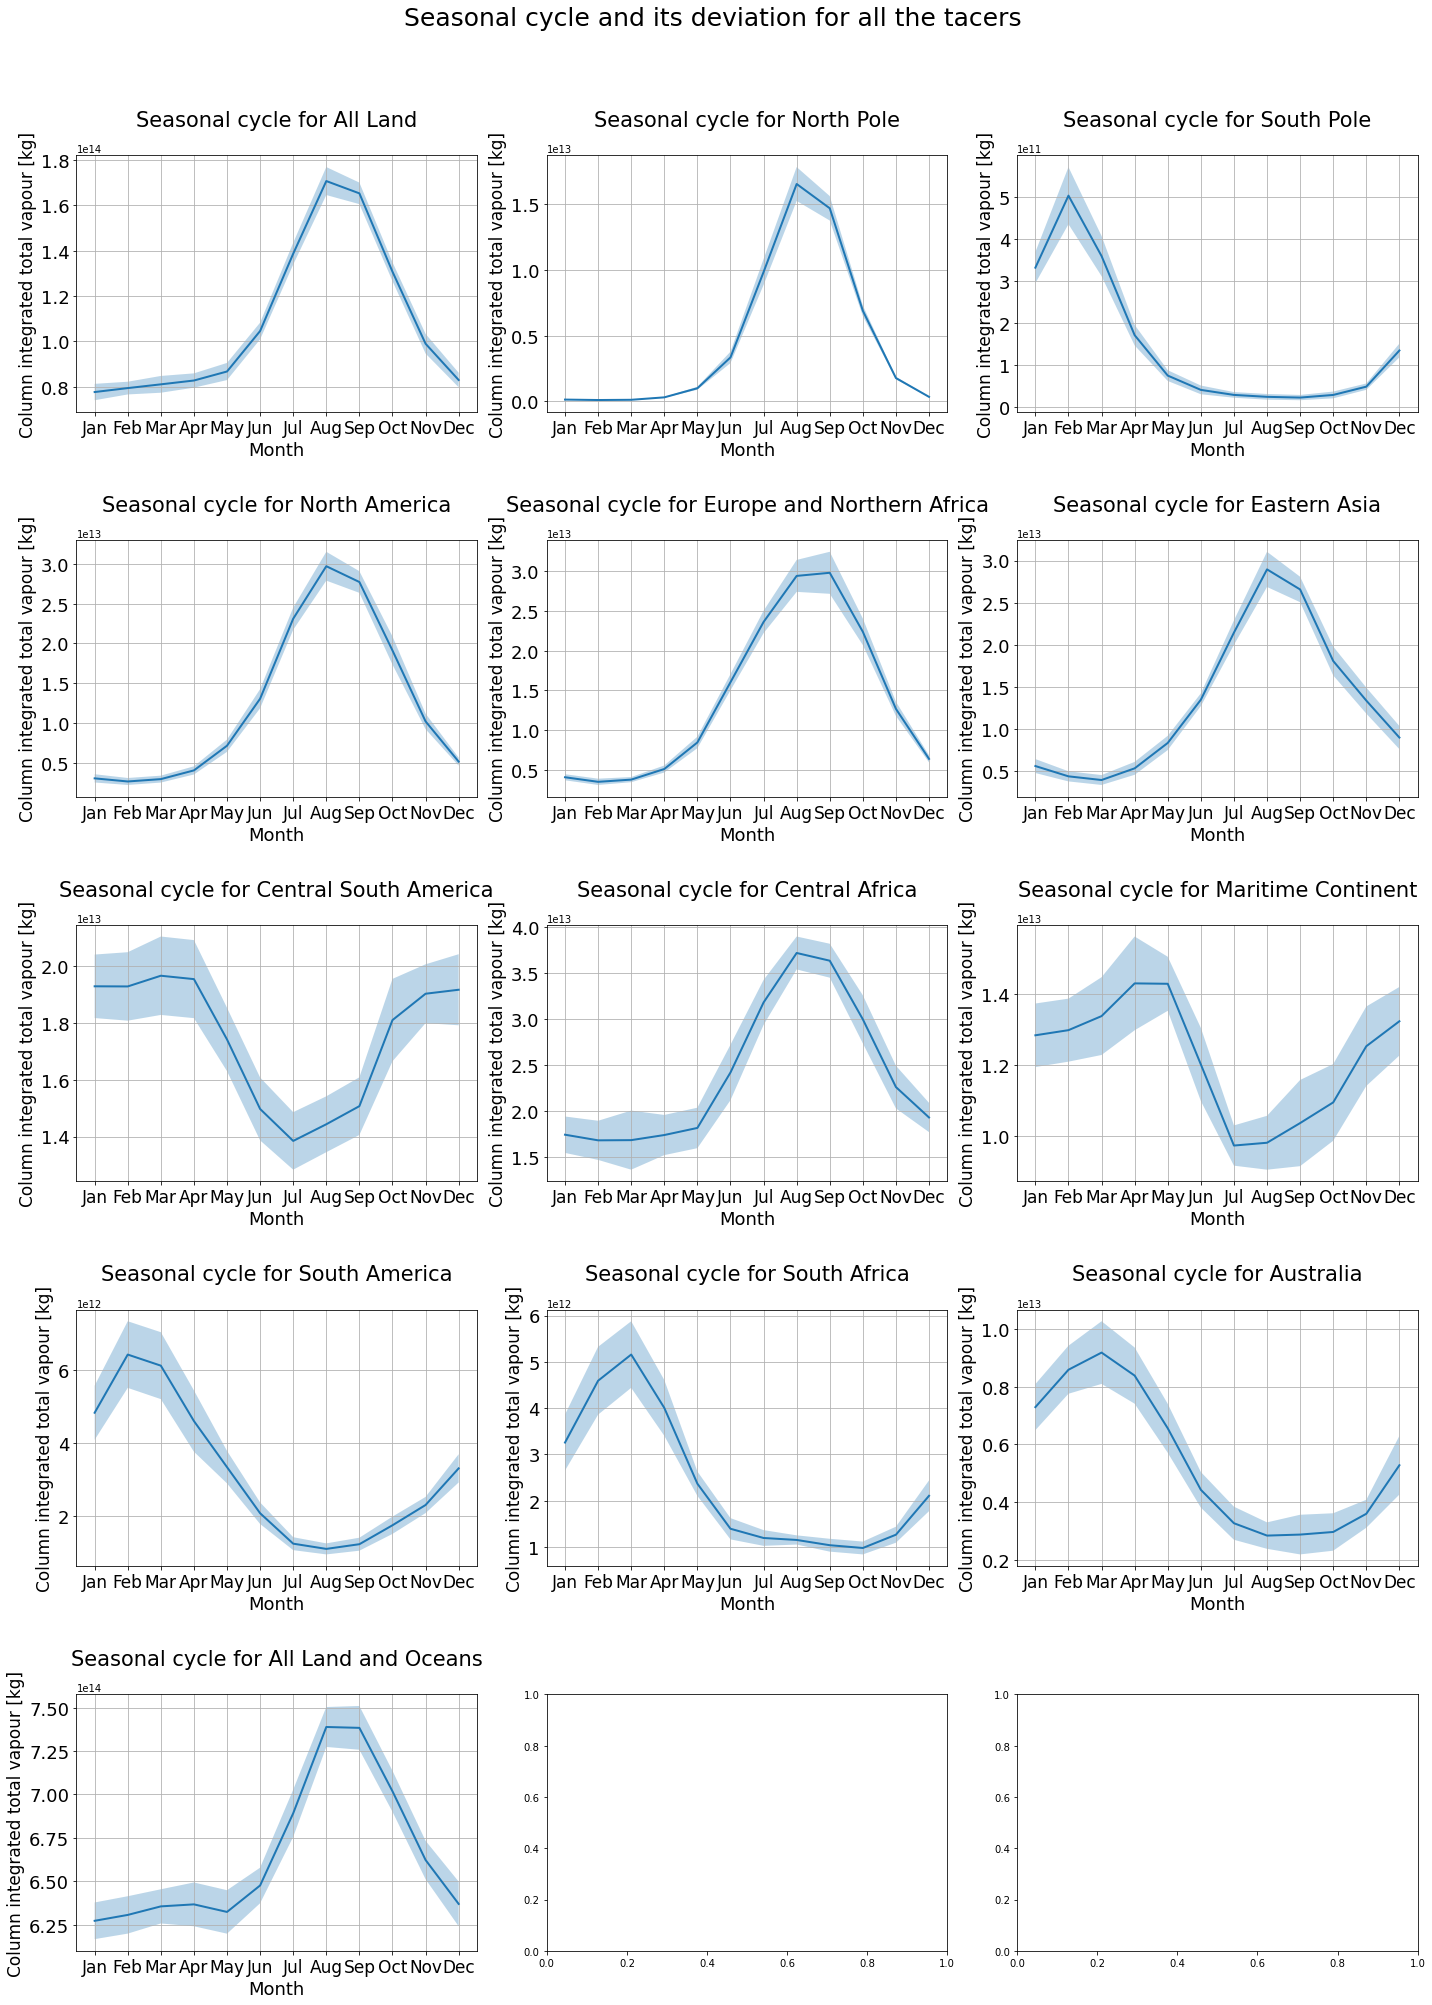

In [10]:
# overall: Annual cycle profile (monthly mean and standard deviation) for each tracer
case = 'amip'
tracer_list = ['LNDV','NPV','SPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'Q']
# figure and axes initialization
fig, axes = plt.subplots(5, 3, figsize=(20, 27))  # 5 rows to fit 13 tracers(12 +total land and ocean water vapour) + text
axes = axes.flatten()
    
seasonal_cycle = {}
for i, tracer in enumerate(tracer_list):
    ax = axes[i]
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # opening stored integrated vapour, shape (lon, lat, time)
    
    # mutiply cell value by its area then sum to have the total  vapour
    ds_weighted = data_integrated * cell_area
    ds_zm = ds_weighted.sum(dim=['lat', 'lon'])# shape (time)
    ds_months =ds_zm.groupby('time.month').mean('time') # shape (month)
    ds_months_std= ds_zm.groupby('time.month').std('time') # standart deviation
    
    # plot the monthly value and fill with the difference between mean and std
    ax.plot(ds_months.month.values, ds_months.values, linewidth=2, label=f'{tracer_dict_reversed[tracer]}')
    ax.fill_between(ds_months.month.values,ds_months.values - ds_months_std.values,
                    ds_months.values + ds_months_std.values, alpha=0.3, label='±1 std dev')
    
    # title and axis names and properties
    ax.set_xticks(ds_months.month.values)
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=17)
    ax.set_xlabel('Month', fontsize=18)
    ax.set_ylabel('Column integrated total vapour [kg]', fontsize=17)
    ax.set_title(f'Seasonal cycle for {tracer_dict_reversed[tracer]}\n', fontsize=21)
    ax.tick_params(axis='y', labelsize=18)#frontsize of axis scale
    
    ax.grid()
    
    # store interesting values for future use
    seasonal_cycle[tracer] = {
        'mean': ds_months.values.mean(),
        'maximum': ds_months.values.max(),
        'minimum': ds_months.values.min(),
        'range':(ds_months.values.max()-ds_months.values.min()),
        'range % max': (100*(ds_months.values.max()-ds_months.values.min())/ds_months.values.max()),
        'std mean': ds_months_std.values.mean(),
        'std mean % mean': 100 * ds_months_std.values.mean() / ds_months.values.mean(),
        'std mean % range':100 * ds_months_std.values.mean() / (ds_months.values.max()-ds_months.values.min()),
        'std minimum': ds_months_std.values.min(),
        'std maximum': ds_months_std.values.max()}
    
#general title
fig.suptitle(f'Seasonal cycle and its deviation for all the tacers ', fontsize=25, y=1.03)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5) 
plt.savefig('seasonal_cycle.svg')
plt.show()
plt.close()    

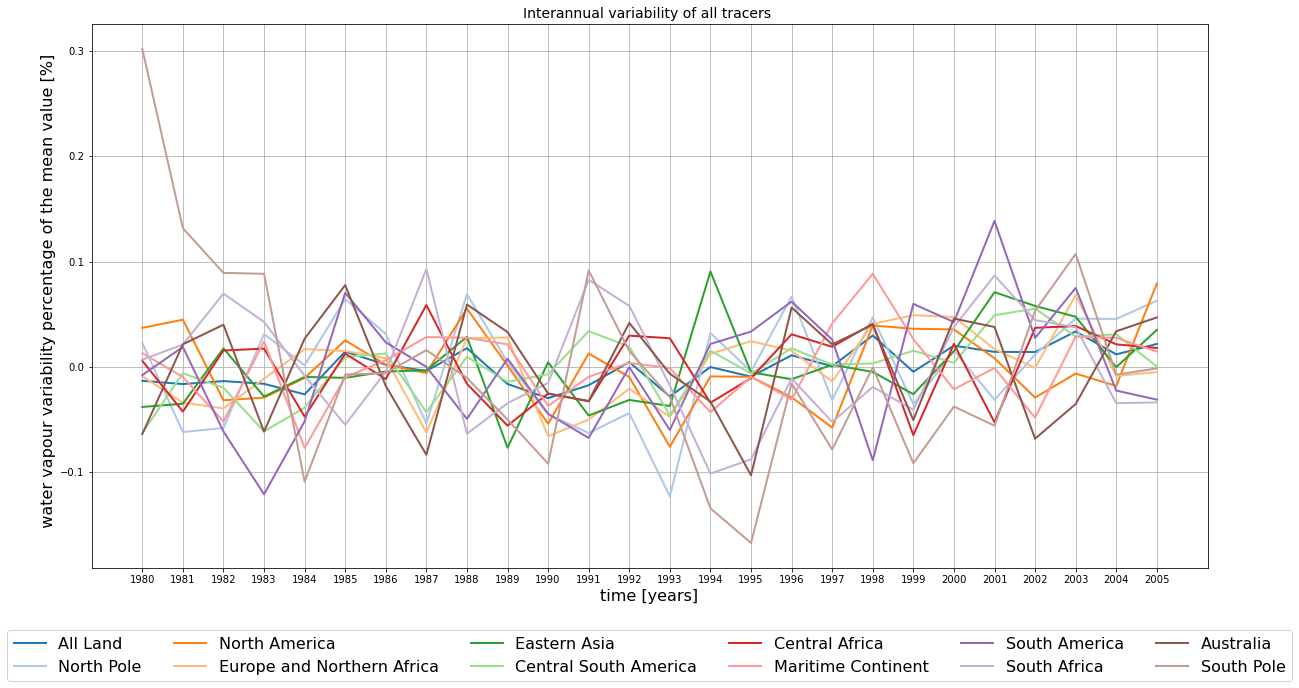

In [16]:
# overall : line plot : for different tracer, interannual variability
tracer_list = ['LNDV','NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']
plt.figure(figsize= (20,10))

for i, tracer in enumerate (tracer_list):
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # opening stored integrated  data, shape (lon, lat, time)
    
    # mutiply cell value by its area then sum to have the total vapour
    ds_weighted = data_integrated * cell_area 
    ds_zm = ds_weighted.sum(dim=['lat', 'lon'])    # shape (time)
    ds_annual_mean = ds_zm.groupby('time.year').mean('time')          # shape (years,)
    ds_mean = ds_annual_mean.mean('year')                       # total mean 
    ds_year_pct =((ds_annual_mean-ds_mean) / ds_mean)  # % anomaly per year
    # plot the yearly  anomaly 
    plt.plot(ds_year_pct.year.values, ds_year_pct.values, linewidth=2,color = plt.cm.tab20.colors [i % 20],label=f'{tracer_dict_reversed[tracer]}')
    
    # axis details and title 
    plt.xticks(ds_annual_mean.year.values)
    plt.xlabel('time [years]', fontsize=16)
    #plt.ylim(0,20)
    plt.ylabel('  water vapour variability percentage of the mean value [%]', fontsize=16)
    #plt.ylim(0,humidity_limit)
    plt.title(f'Interannual variability of all tracers ', fontsize=14)
    
plt.grid()
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.1),ncol=6)
plt.show()



### table of statistic data

In [17]:
#Overall :check with the evaporation if it is coherent with the moisture mean /surface

#open the land evaporation data
evaporation_path = Path(data_dir) / 'icesm_continents_sst' / 'TimeSeries' / 'icesm_continents_sst.clm2.h0.ts.0-end.EFLX_LH_TOT_R.nc'
ds_land_evap = xr.open_dataset(evaporation_path)
land_evap = ds_land_evap['EFLX_LH_TOT_R'].load()
land_evap = land_evap.assign_coords(lat=landfrac.lat, lon=landfrac.lon)

# create empty dictionary to store zonal limits and evaporation values 
land_evap_dict={}
evap = {}


for tracer, region in tracer_regions.items():
    # determine max and min lat and lon for each tracer and store it 
    lat_min, lat_max = region['lat']
    lon_min, lon_max = region['lon']
    if lon_min <= lon_max:
        land_evap_dict[tracer] = land_evap.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    else:
        lat_mask_evap = land_evap.sel(lat=slice(lat_min, lat_max))
        land_evap_dict[tracer] = xr.concat([lat_mask_evap.sel(lon=slice(lon_min, 360)), lat_mask_evap.sel(lon=slice(0, lon_max))], dim="lon",)

    weights = np.cos(np.deg2rad(land_evap_dict[tracer].lat)) # weight
    zs_evap = land_evap_dict[tracer].weighted(weights).mean(dim=['lat', 'lon'])# weighted mean, shape (time)
    evap[tracer] = zs_evap.mean(dim='time') # store it 

    print(f'{tracer} mean /surface land tracer [W/m2land] : {evap[tracer].values}')

LNDV mean /surface land tracer [W/m2land] : 46.999267578125
NPV mean /surface land tracer [W/m2land] : 12.992857933044434
NAV mean /surface land tracer [W/m2land] : 38.53462600708008
EUV mean /surface land tracer [W/m2land] : 19.847606658935547
EAV mean /surface land tracer [W/m2land] : 35.538291931152344
CSAV mean /surface land tracer [W/m2land] : 90.52184295654297
CAFV mean /surface land tracer [W/m2land] : 59.68091583251953
MARV mean /surface land tracer [W/m2land] : 99.963623046875
SAV mean /surface land tracer [W/m2land] : 51.36268615722656
SAFV mean /surface land tracer [W/m2land] : 47.312522888183594
AUSV mean /surface land tracer [W/m2land] : 43.716705322265625
SPV mean /surface land tracer [W/m2land] : nan


In [18]:
#Overall: statistic tables with all the data
#Table with the statistic values of the annual profile 
rows= []
tracer_list = ['LNDV','NPV','SPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV']
for tracer in tracer_list : 
    data=seasonal_cycle[tracer]
    rows.append({
        'tracer': tracer,
        'mean [10^12 kg]' : f"{(data['mean']/1e12):.2f}",
        'maximum [10^12 kg]': f"{(data['maximum']/1e12):.2f}",
        'minimum [10^12 kg]': f"{(data['minimum']/1e12):.2f}",
        'range [10^12 kg]': f"{(data['range']/1e12):.2f}",
        'range % max [%]': f"{data['range % max']:.1f}%",
        'std mean [10^12 kg]' : f"{(data['std mean']/1e12):.2f}",
        #'std mean % mean [%]': f"{data['std mean % mean']:.1f}%",
        'std mean / range [%]': f"{data['std mean % range']:.1f}%",
        'std min [10^12 kg]' : f"{(data['std minimum']/1e12):.2f}",
        'std max [10^12 kg]': f"{(data['std maximum']/1e12):.2f}",
        'mean/tracer land [kg/m2]' : f"{data['mean'] / surface_land_cells_dict[tracer].item():.2f}",
        #'land evap [W/m2]' : f"{evap[tracer].values:.2f}"
    })
table_seasonal_cycle = pd.DataFrame(rows).set_index('tracer')
display(table_seasonal_cycle.style.set_properties(**{'width': '100px'}))

print ('std/mean',seasonal_cycle['Q']['std mean % mean'], 'std/range',seasonal_cycle['Q']['std mean % range'])
  # interesting values for total Q 
    

,mean [10^12 kg],maximum [10^12 kg],minimum [10^12 kg],range [10^12 kg],range % max [%],std mean [10^12 kg],std mean / range [%],std min [10^12 kg],std max [10^12 kg],mean/tracer land [kg/m2]
tracer,,,,,,,,,,
LNDV,108.33,170.72,77.72,93.00,54.5%,4.01,4.3%,2.81,6.17,0.73
NPV,4.60,16.56,0.10,16.46,99.4%,0.36,2.2%,0.02,1.29,0.27
SPV,0.15,0.50,0.02,0.48,95.5%,0.02,4.4%,0.01,0.07,0.01
NAV,12.32,29.72,2.64,27.07,91.1%,0.98,3.6%,0.43,1.81,0.78
EUV,13.76,29.80,3.50,26.30,88.3%,1.03,3.9%,0.33,2.64,0.68
EAV,13.20,28.95,3.93,25.02,86.4%,1.17,4.7%,0.59,2.09,0.52
CSAV,17.48,19.65,13.85,5.80,29.5%,1.17,20.1%,0.98,1.45,1.26
CAFV,23.96,37.14,16.78,20.36,54.8%,2.28,11.2%,1.59,3.21,1.10
MARV,12.19,14.29,9.73,4.57,32.0%,0.97,21.3%,0.57,1.32,1.65


std/mean 1.7548868856240822 std/range 10.451626326137104


### Map plot

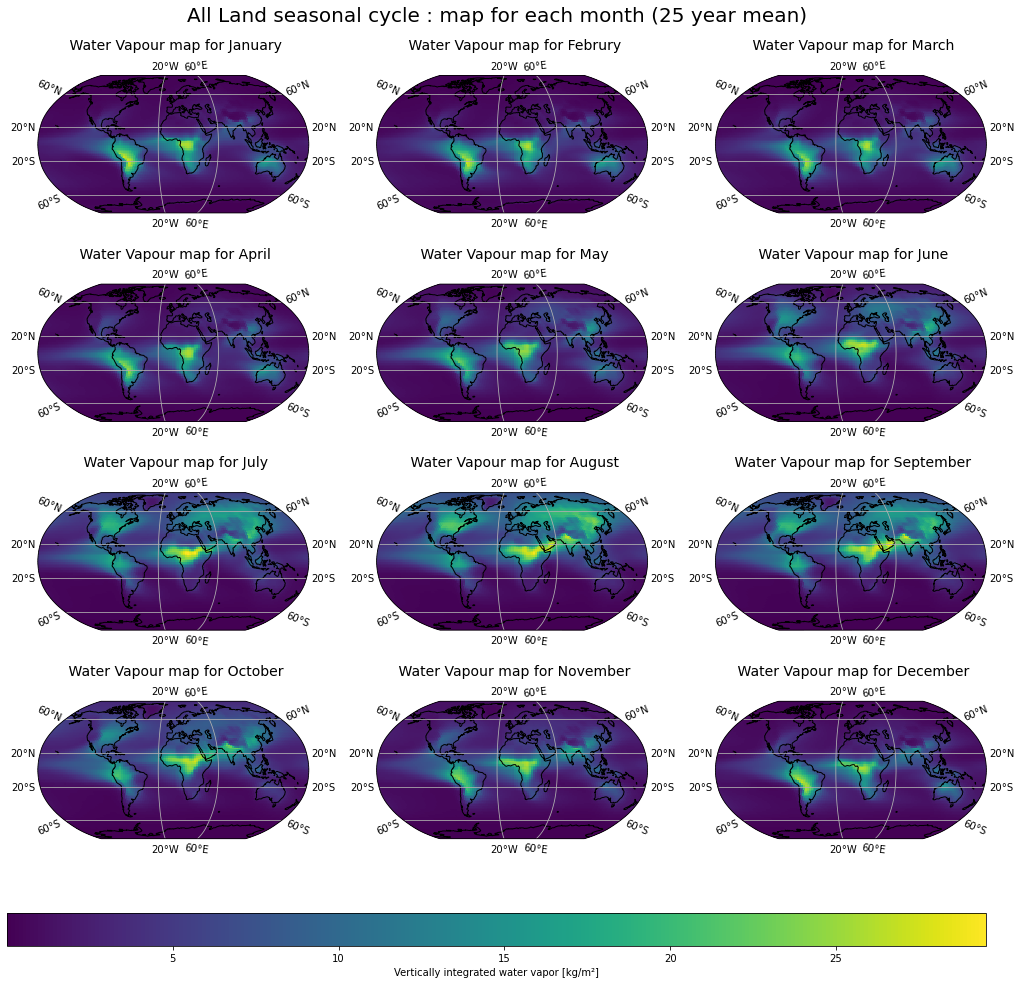

In [19]:
## Robinson map for each month (mean over the years) for one tracer
case = 'amip'
tracer_list = ['LNDV'] # tracer choice
for tracer in tracer_list:
    # figure with 12 maps
    fig = plt.figure(figsize=(17, 15))
    gs = fig.add_gridspec(4, 3, hspace=0.1, wspace = 0.25)
    ax_list = [fig.add_subplot(gs[i // 3, i % 3], projection=ccrs.Robinson()) for i in range(12)] # 12 locations with empty maps
    
    # open stored intagrated data and untack it
    ds_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc")  #shape (lon, lat, time)
    ds_month_mean  = unstack_time(ds_integrated).mean('year') # unstack to have time=yearsxmonths, mean each month over the years
    
    for i, months in enumerate(ds_month_mean.month.values):    
        ax = ax_list[i]  
        ds_months = ds_month_mean.sel(month=months) # shape (lon, lat)
        data_plot, lon_plot = add_cyclic_point(ds_months.values, coord=ds_months.lon.values)   # Add cyclic pointto avoid white line
        
        # plot latxlon data for the selected month
        figure = ax.pcolormesh(lon_plot, ds_months.lat.values, data_plot,transform=ccrs.PlateCarree(), cmap='viridis',
                       vmin=ds_month_mean.values.min(), vmax=ds_month_mean.values.max(), shading='auto') 
        
        #addfigure title,  colobar  and its title, coastlines and gridlines 
        ax.set_title(f' Water Vapour map for {months_name[months]}', fontsize=14, pad=10) 
        ax.coastlines()
        ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
        
    cax = fig.add_axes([0.1, 0.05, 0.8, 0.03])  # location [left, bottom, width, height] of the colorbar
    fig.colorbar(figure, cax=cax, orientation='horizontal',label='Vertically integrated water vapor [kg/m²]')# colorbar
    fig.suptitle(f'{tracer_dict_reversed[tracer]} seasonal cycle : map for each month (25 year mean)', fontsize=20, y=0.92) # fig title 
    plt.show()